In [1]:
!pip install matplotlib numpy transformers medmnist scikit-learn torch torchvision scipy seaborn

# Notebook 1 — Data Exploration & Verification

Explore the PathMNIST dataset visually and run exhaustive data-quality checks.

**Classes used:**
- Label **6** — Normal Colon Mucosa (hard negative: looks similar to tumour)
- Label **8** — Colorectal Adenocarcinoma (the target tumour class)

**Clinical scenario:** 1 tumour patch hidden among 99 normal patches per patient
(simulating pre-screening for very small, early-stage colorectal cancer).

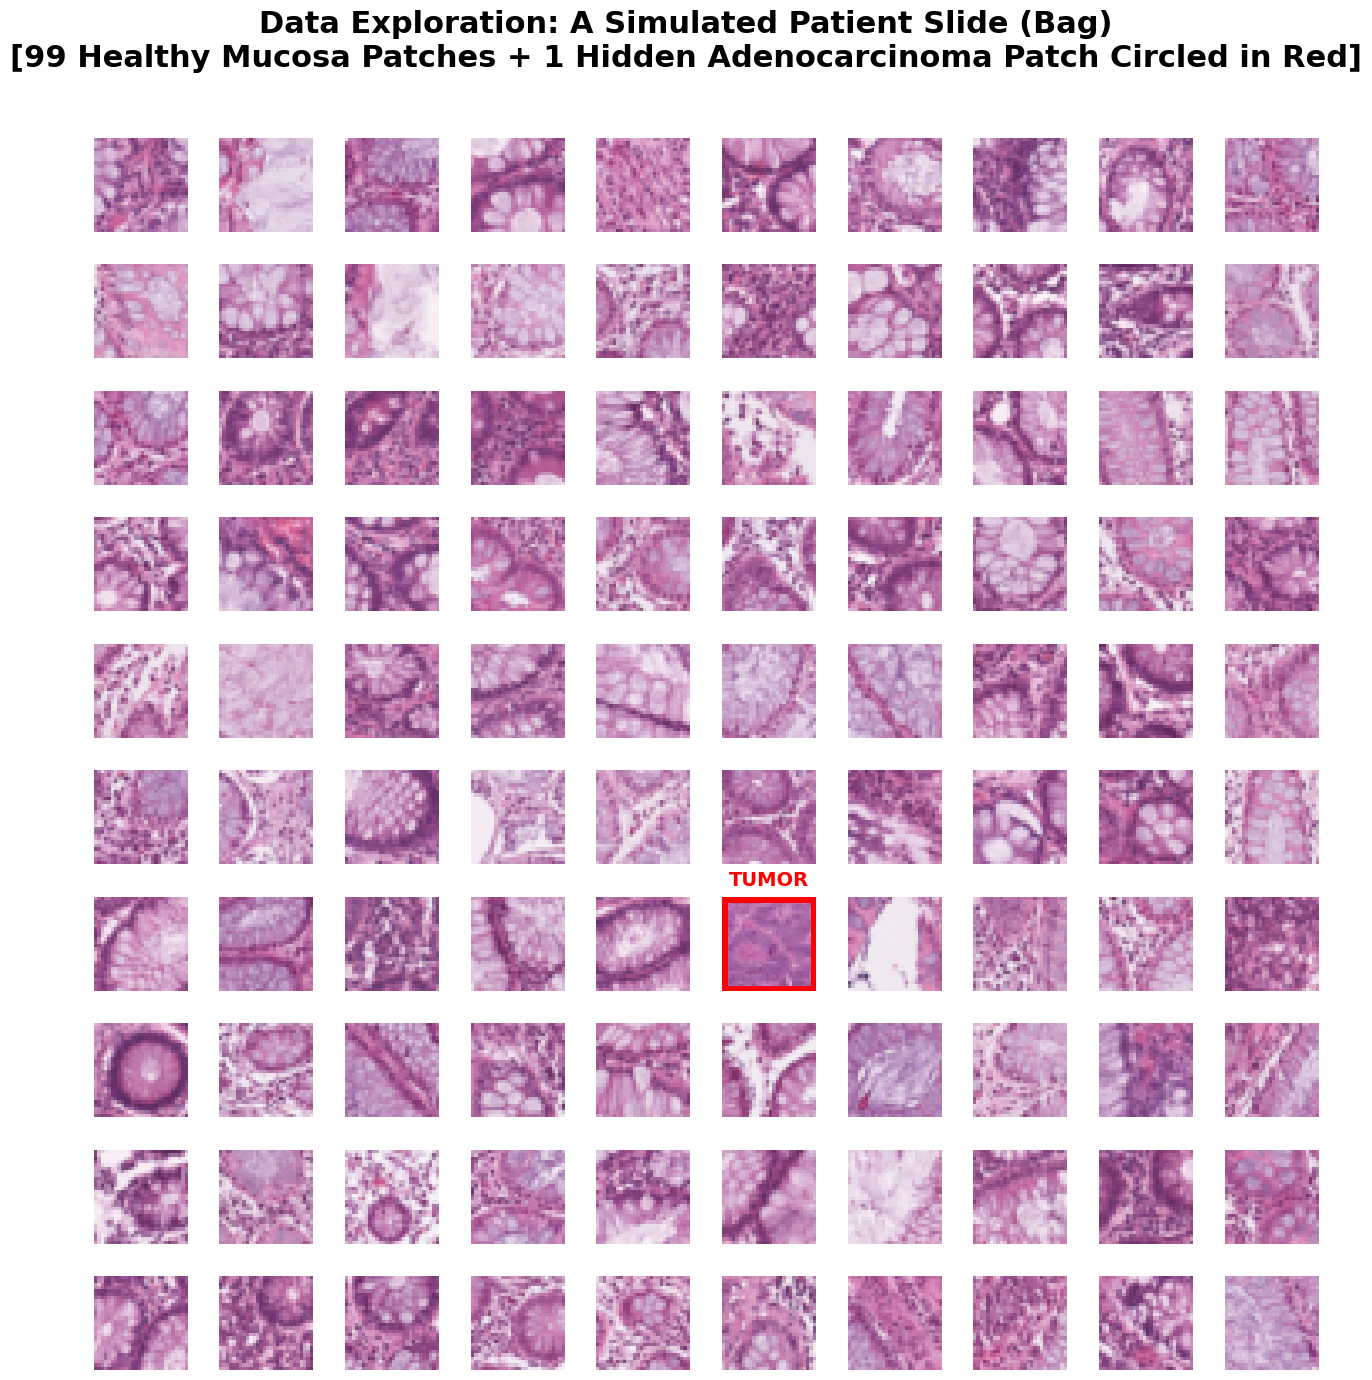

Tumour hidden at Grid Position #65 (Row 6, Col 5).


In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import medmnist
from medmnist import INFO

info      = INFO['pathmnist']
DataClass = getattr(medmnist, info['python_class'])
train_data = DataClass(split='train', download=True)

train_labels = train_data.labels.squeeze()
train_images = train_data.imgs

train_tumor_idx       = np.where(train_labels == 8)[0]
train_hard_normal_idx = np.where(train_labels == 6)[0]

# ── 10x10 Patient Slide Grid (1% Tumour Signal) ───────────────────────────────
np.random.seed(42)
tumor_patch_source    = np.random.choice(train_tumor_idx, 1, replace=False)
normal_patches_source = np.random.choice(train_hard_normal_idx, 99, replace=False)
bag_indices           = np.concatenate([tumor_patch_source, normal_patches_source])

shuffle_order          = np.random.permutation(100)
shuffled_bag_indices   = bag_indices[shuffle_order]
tumor_position_in_grid = np.where(shuffle_order == 0)[0][0]

fig, axes = plt.subplots(10, 10, figsize=(16, 16))
fig.suptitle(
    "Data Exploration: A Simulated Patient Slide (Bag)\n"
    "[99 Healthy Mucosa Patches + 1 Hidden Adenocarcinoma Patch Circled in Red]",
    fontsize=22, fontweight='bold', y=0.96)

for i in range(100):
    row, col = i // 10, i % 10
    axes[row, col].imshow(train_images[shuffled_bag_indices[i]])
    axes[row, col].axis('off')
    if i == tumor_position_in_grid:
        rect = mpatches.Rectangle((0, 0), 27, 27, linewidth=5,
                                   edgecolor='red', facecolor='none')
        axes[row, col].add_patch(rect)
        axes[row, col].set_title("TUMOR", color='red', fontsize=14,
                                  fontweight='bold', pad=8)

plt.subplots_adjust(wspace=0.15, hspace=0.35)
plt.show()
print(f"Tumour hidden at Grid Position #{tumor_position_in_grid} "
      f"(Row {tumor_position_in_grid//10}, Col {tumor_position_in_grid%10}).")


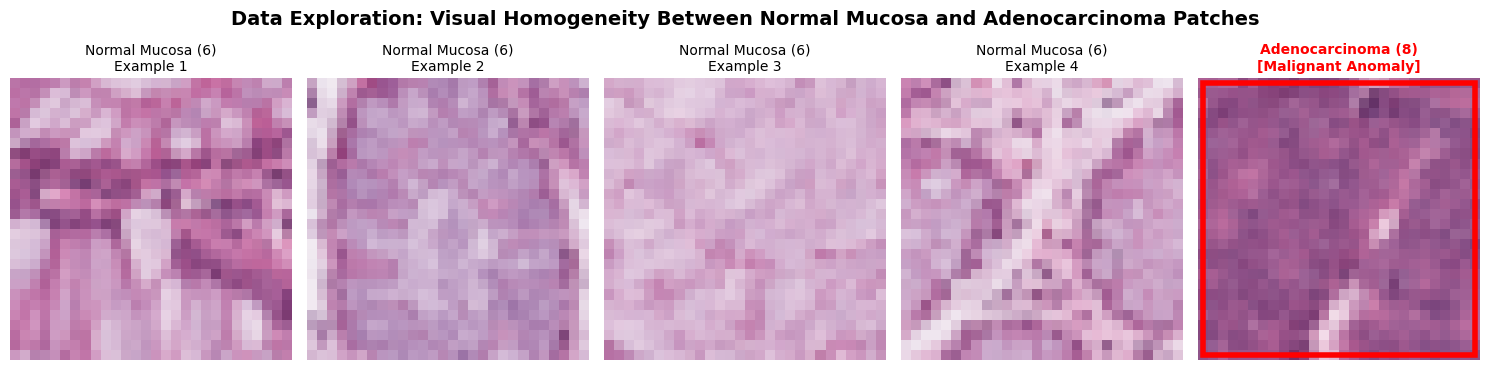

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import medmnist
from medmnist import INFO

info      = INFO['pathmnist']
DataClass = getattr(medmnist, info['python_class'])
train_data = DataClass(split='train', download=True)

train_labels = train_data.labels.squeeze()
train_images = train_data.imgs
train_tumor_idx       = np.where(train_labels == 8)[0]
train_hard_normal_idx = np.where(train_labels == 6)[0]

np.random.seed(42)
selected_normal_idx = np.random.choice(train_hard_normal_idx, 4, replace=False)
selected_tumor_idx  = np.random.choice(train_tumor_idx, 1, replace=False)

fig, axes = plt.subplots(1, 5, figsize=(15, 3.5))
fig.suptitle(
    "Data Exploration: Visual Homogeneity Between "
    "Normal Mucosa and Adenocarcinoma Patches",
    fontsize=14, fontweight='bold', y=1.05)

for i in range(4):
    axes[i].imshow(train_images[selected_normal_idx[i]])
    axes[i].set_title(f"Normal Mucosa (6)\nExample {i+1}", fontsize=10)
    axes[i].axis('off')

axes[4].imshow(train_images[selected_tumor_idx[0]])
axes[4].set_title("Adenocarcinoma (8)\n[Malignant Anomaly]",
                   color='red', fontsize=10, fontweight='bold')
axes[4].axis('off')
axes[4].add_patch(
    mpatches.Rectangle((0, 0), 27, 27, linewidth=4,
                        edgecolor='red', facecolor='none'))

plt.tight_layout()
plt.show()


---
### Dataset Statistics & Class Distribution

Before building bags we examine pixel statistics and label imbalance in the full
PathMNIST training set (all 9 classes), then zoom in on our two classes.

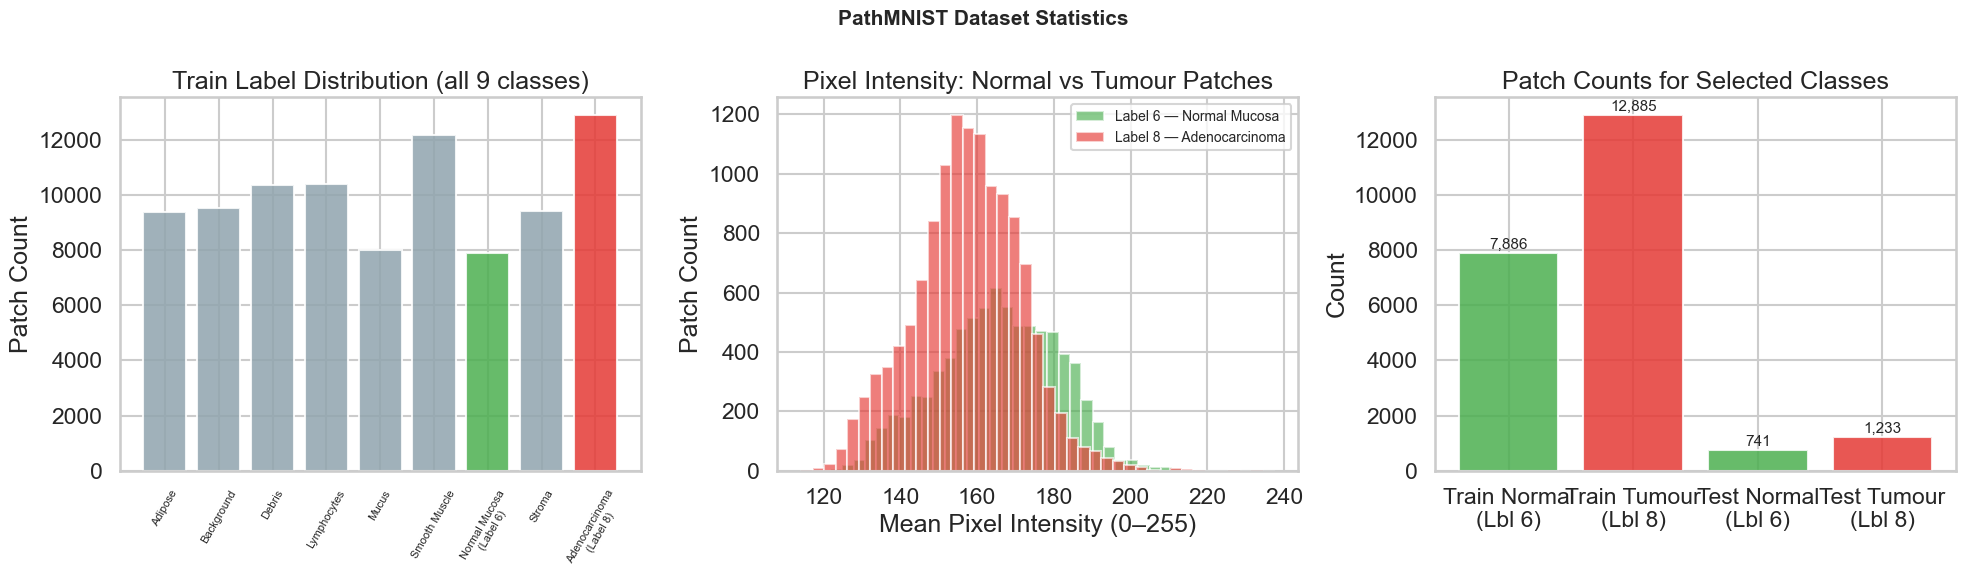


Dataset summary:
  Train images : (89996, 28, 28, 3)  dtype: uint8
  Test  images : (7180, 28, 28, 3)   dtype: uint8
  Pixel range  : [0, 255]
  Train label 6: 7,886  |  label 8: 12,885
  Test  label 6: 741   |  label 8: 1,233


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import medmnist
from medmnist import INFO

sns.set_theme(style='whitegrid', context='talk')

info      = INFO['pathmnist']
DataClass = getattr(medmnist, info['python_class'])
train_data = DataClass(split='train', download=True)
test_data  = DataClass(split='test',  download=True)

train_labels = train_data.labels.squeeze()
test_labels  = test_data.labels.squeeze()
train_images = train_data.imgs
test_images  = test_data.imgs

LABEL_NAMES = {
    0: 'Adipose', 1: 'Background', 2: 'Debris',
    3: 'Lymphocytes', 4: 'Mucus', 5: 'Smooth Muscle',
    6: 'Normal Mucosa\n(Label 6)', 7: 'Stroma',
    8: 'Adenocarcinoma\n(Label 8)'
}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("PathMNIST Dataset Statistics", fontsize=15, fontweight='bold')

# Label distribution (train)
train_counts = Counter(train_labels.tolist())
labels_sorted = sorted(train_counts.keys())
counts_sorted = [train_counts[l] for l in labels_sorted]
bar_colors = ['#E53935' if l == 8 else ('#4CAF50' if l == 6 else '#90A4AE')
              for l in labels_sorted]
axes[0].bar([LABEL_NAMES.get(l, str(l)) for l in labels_sorted],
            counts_sorted, color=bar_colors, alpha=0.85)
axes[0].set_title("Train Label Distribution (all 9 classes)")
axes[0].set_ylabel("Patch Count")
axes[0].tick_params(axis='x', rotation=60)
axes[0].tick_params(axis='x', labelsize=8)

# Pixel intensity distribution for our 2 classes
n6_imgs = train_images[train_labels == 6].astype(float).mean(axis=(1, 2, 3))
n8_imgs = train_images[train_labels == 8].astype(float).mean(axis=(1, 2, 3))
axes[1].hist(n6_imgs, bins=40, color='#4CAF50', alpha=0.65,
             label='Label 6 — Normal Mucosa')
axes[1].hist(n8_imgs, bins=40, color='#E53935', alpha=0.65,
             label='Label 8 — Adenocarcinoma')
axes[1].set_xlabel("Mean Pixel Intensity (0–255)")
axes[1].set_ylabel("Patch Count")
axes[1].set_title("Pixel Intensity: Normal vs Tumour Patches")
axes[1].legend(fontsize=10)

# Train vs test size for our 2 classes
cats  = ['Train Normal\n(Lbl 6)', 'Train Tumour\n(Lbl 8)',
         'Test Normal\n(Lbl 6)',  'Test Tumour\n(Lbl 8)']
cnts  = [int((train_labels==6).sum()), int((train_labels==8).sum()),
         int((test_labels==6).sum()),  int((test_labels==8).sum())]
cols  = ['#4CAF50', '#E53935', '#4CAF50', '#E53935']
bars  = axes[2].bar(cats, cnts, color=cols, alpha=0.85, edgecolor='white')
for bar, n in zip(bars, cnts):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{n:,}', ha='center', va='bottom', fontsize=11)
axes[2].set_title("Patch Counts for Selected Classes")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()

print("\nDataset summary:")
print(f"  Train images : {train_images.shape}  dtype: {train_images.dtype}")
print(f"  Test  images : {test_images.shape}   dtype: {test_images.dtype}")
print(f"  Pixel range  : [{train_images.min()}, {train_images.max()}]")
print(f"  Train label 6: {int((train_labels==6).sum()):,}  |  label 8: {int((train_labels==8).sum()):,}")
print(f"  Test  label 6: {int((test_labels==6).sum()):,}   |  label 8: {int((test_labels==8).sum()):,}")


---
### Data Quality Verification

Full suite of checks: NaN / Inf detection, shape validation, class presence,
and patch-pool consistency — defined as reusable functions.

In [5]:
import numpy as np
from collections import Counter


def print_section(title):
    print("\n" + "=" * 70)
    print(title)
    print("=" * 70)


def verify_raw_pathmnist(images, labels, normal_label=6, malignant_label=8):
    print_section("1. RAW PATHMNIST DATA VERIFICATION")
    images = np.array(images)
    labels = np.array(labels).reshape(-1)
    print(f"Images shape : {images.shape}  dtype: {images.dtype}")
    print(f"Labels shape : {labels.shape}  dtype: {labels.dtype}")
    print(f"Image-label count match : {len(images) == len(labels)}")
    print(f"Images contain NaN : {np.isnan(images.astype(float)).any()}")
    print(f"Images contain Inf : {np.isinf(images.astype(float)).any()}")
    print(f"Labels contain NaN : {np.isnan(labels.astype(float)).any()}")
    unique_labels = sorted(np.unique(labels).tolist())
    label_counts  = dict(Counter(labels.tolist()))
    print(f"Unique labels       : {unique_labels}")
    print(f"Label distribution  : {label_counts}")
    n_count = int(np.sum(labels == normal_label))
    m_count = int(np.sum(labels == malignant_label))
    print(f"Normal (Lbl {normal_label}) count      : {n_count:,}")
    print(f"Malignant (Lbl {malignant_label}) count : {m_count:,}")
    print(f"Both classes present : {'YES' if n_count > 0 and m_count > 0 else 'NO'}")
    return {"num_images": len(images), "num_labels": len(labels),
            "contains_nan_images": bool(np.isnan(images.astype(float)).any()),
            "unique_labels": unique_labels, "label_distribution": label_counts,
            "normal_count": n_count, "malignant_count": m_count}


def verify_patch_pools(normal_images, malignant_images):
    print_section("2. PATCH POOL VERIFICATION")
    n = np.array(normal_images)
    m = np.array(malignant_images)
    print(f"Normal pool shape    : {n.shape}")
    print(f"Malignant pool shape : {m.shape}")
    print(f"Normal    NaN : {np.isnan(n).any()}   Inf : {np.isinf(n).any()}")
    print(f"Malignant NaN : {np.isnan(m).any()}   Inf : {np.isinf(m).any()}")
    print(f"Same patch shape : {n.shape[1:] == m.shape[1:]}")
    return {"normal_shape": n.shape, "malignant_shape": m.shape,
            "same_patch_shape": n.shape[1:] == m.shape[1:]}


def verify_patient_bags(X_bags, y_bags, expected_patches=100,
                         expected_emb_dim=768, name="Bags"):
    print_section(f"3. {name.upper()} VERIFICATION")
    X = np.array(X_bags)
    y = np.array(y_bags).reshape(-1)
    print(f"X shape : {X.shape}   y shape : {y.shape}")
    print(f"Bag-label count match : {X.shape[0] == len(y)}")
    if X.ndim == 3:
        print(f"Patches per bag      : {X.shape[1]}  (expected {expected_patches})")
        print(f"Embedding dim        : {X.shape[2]}  (expected {expected_emb_dim})")
        print(f"Patches/bag correct  : {X.shape[1] == expected_patches}")
        print(f"Embedding dim correct: {X.shape[2] == expected_emb_dim}")
    print(f"NaN : {np.isnan(X).any()}   Inf : {np.isinf(X).any()}")
    dist = dict(Counter(y.tolist()))
    pos  = int(np.sum(y == 1))
    neg  = int(np.sum(y == 0))
    print(f"Label distribution   : {dist}")
    print(f"Positive bags : {pos}   Negative bags : {neg}")
    return {"shape": X.shape, "label_dist": dist, "positive": pos, "negative": neg}


def verify_train_test_separation(train_patch_ids, test_patch_ids):
    print_section("4. TRAIN / TEST LEAKAGE CHECK")
    tr = set(train_patch_ids)
    te = set(test_patch_ids)
    ov = tr & te
    print(f"Unique train patch IDs : {len(tr):,}")
    print(f"Unique test  patch IDs : {len(te):,}")
    print(f"Strict overlap count   : {len(ov)}")
    print(f"Leakage check : {'PASSED' if len(ov)==0 else 'FAILED'}")
    return {"overlap_count": len(ov), "passed": len(ov) == 0}


def run_full_verification(train_images, train_labels, test_images, test_labels,
                           normal_label=6, malignant_label=8):
    print_section("FULL DATA QUALITY VERIFICATION")
    r1 = verify_raw_pathmnist(train_images, train_labels, normal_label, malignant_label)
    r2 = verify_patch_pools(
        train_images[train_labels == normal_label],
        train_images[train_labels == malignant_label])
    print_section("SUMMARY")
    all_ok = (not r1["contains_nan_images"] and
              r1["normal_count"] > 0 and r1["malignant_count"] > 0 and
              r2["same_patch_shape"])
    print(f"Overall status: {'ALL CHECKS PASSED' if all_ok else 'SOME CHECKS FAILED'}")
    return {"raw": r1, "pools": r2}


In [6]:
import medmnist
from medmnist import INFO
import numpy as np

info      = INFO['pathmnist']
DataClass = getattr(medmnist, info['python_class'])
train_data = DataClass(split='train', download=True)
test_data  = DataClass(split='test',  download=True)

train_images = train_data.imgs
train_labels = train_data.labels.squeeze()
test_images  = test_data.imgs
test_labels  = test_data.labels.squeeze()

report = run_full_verification(train_images, train_labels,
                                test_images,  test_labels,
                                normal_label=6, malignant_label=8)



FULL DATA QUALITY VERIFICATION

1. RAW PATHMNIST DATA VERIFICATION
Images shape : (89996, 28, 28, 3)  dtype: uint8
Labels shape : (89996,)  dtype: uint8
Image-label count match : True


Images contain NaN : False


Images contain Inf : False
Labels contain NaN : False
Unique labels       : [0, 1, 2, 3, 4, 5, 6, 7, 8]
Label distribution  : {0: 9366, 4: 8006, 7: 9401, 5: 12182, 8: 12885, 3: 10401, 2: 10360, 1: 9509, 6: 7886}
Normal (Lbl 6) count      : 7,886
Malignant (Lbl 8) count : 12,885
Both classes present : YES



2. PATCH POOL VERIFICATION
Normal pool shape    : (7886, 28, 28, 3)
Malignant pool shape : (12885, 28, 28, 3)
Normal    NaN : False   Inf : False
Malignant NaN : False   Inf : False
Same patch shape : True

SUMMARY
Overall status: ALL CHECKS PASSED
